# Workload — Mental-demand Mechanism Check (F1 / F2 / F3)

> A single mental-effort slider after each block: “How mentally demanding or
> overwhelming did this block feel?” *(very low–very high)*

**Why it matters.** The reasoning behind H2–H4 is that the contrastive forms
(F2/F3) make the *same* information **easier to process under load**, freeing
attention to redeploy onto the events and tasks that matter. Perceived mental
demand is the direct check on that mechanism: if F2/F3 really are easier to read
under multitasking load, workload should be **lower under F2/F3** than under the
verbose stream **F1** — even though every form delivers identical content. This
notebook tests that mechanism descriptively and relates it to the explicability
composite (H2).

**Design**

| Role | Variable | Detail |
|------|----------|--------|
| Independent variable | Explanation **form** | F1 verbose · F2 contrastive · F3 contrastive + actionable. **Within-subjects** — each participant sees all three (Latin-square counterbalanced), each paired with a different gauge set (A/B/C). |
| Measure | **Mental demand** | `workload` ∈ [1, 7], a single mental-effort slider asked *last* each block. Higher = the block felt more demanding. |

## How the workload check is measured

A single `genericscales` slider (`Workload_overall`, 1–7) is presented **last**
after each block — after the objective probe (H2) and the subjective items (H1) —
so that rating effort does not contaminate the earlier measures. It is read
straight through by `matb_analysis/metrics_questionnaire.py` into the `workload`
column (no reverse-keying, no compositing). Because the task structure, event
count, and information content are held constant across forms, a difference in
`workload` between forms reflects the *cost of processing the wording*, which is
exactly the load the contrastive forms are meant to reduce.

We report **descriptive statistics and visualisations**; the closing section
states the statistical approach and the test that applies to this design.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matb_analysis.aggregate import build_metrics_table
from matb_analysis.discovery import find_study_sessions, DEFAULT_SESSIONS_DIR
from matb_analysis.validation import validate_sessions

sns.set_theme(style="whitegrid")
FORM_ORDER = ["F1", "F2", "F3"]
FORM_LABELS = {"F1": "F1\nverbose", "F2": "F2\ncontrastive", "F3": "F3\n+actionable"}
OUT = Path.cwd().parent / "outputs"
OUT.mkdir(exist_ok=True)

# Read the curated study sessions from session_logs/. Whichever candidate
# directory actually contains study sessions is used, so this runs unchanged
# as real participants are collected.
CANDIDATES = [Path.cwd().parent / "session_logs", DEFAULT_SESSIONS_DIR]
DATA_DIR = next((d for d in CANDIDATES if find_study_sessions(d)), CANDIDATES[0])

## 1. Load the sessions and build the workload metrics table

`find_study_sessions()` reads every study session under `DATA_DIR`. Each session
contributes three rows (one per form). The mental-demand rating is read straight
into the `workload` column by `build_metrics_table()`.

In [2]:
sessions = find_study_sessions(DATA_DIR)
print(f"Reading logs from: {DATA_DIR}")
print(f"Discovered {len(sessions)} study session(s).")

table = build_metrics_table(sessions)
(table[["participant", "form", "block", "workload"]]
    .sort_values(["participant", "form"]).reset_index(drop=True))

Reading logs from: c:\Projects\HumanCenteredAI\Analysis\session_logs
Discovered 12 study session(s).


,participant,form,block,workload
0,P01,F1,A,6.091388
1,P01,F2,B,3.071145
2,P01,F3,C,6.026297
3,P02,F1,A,2.993035
4,P02,F2,C,6.449391
5,P02,F3,B,4.828614
6,P03,F1,B,3.572349
7,P03,F2,A,4.000000
8,P03,F3,C,2.198919
9,P04,F1,C,5.128035


### 1b. Sanity check: design realised as intended

Each session is cross-checked against the Latin-square design (form ↔ block order,
panel form vs. briefing). Every participant should contribute exactly one block per
form, so that each form is rated against all three gauge sets equally across the
cohort. Any `ok = False` row must be resolved before trusting that session.

In [3]:
report = validate_sessions(sessions)
n_bad = int((~report["ok"]).sum()) if not report.empty else 0
print(f"{len(report)} session(s) validated; {n_bad} with design issues.")

print(f"\nParticipants: {table['participant'].nunique()}")
print("Blocks per form (should be equal):")
print(table["form"].value_counts().reindex(FORM_ORDER).to_string())
print("\nform x gauge-set (counterbalancing):")
print(pd.crosstab(table["form"], table["block"]).reindex(FORM_ORDER).to_string())

12 session(s) validated; 0 with design issues.

Participants: 12
Blocks per form (should be equal):
form
F1    12
F2    12
F3    12

form x gauge-set (counterbalancing):
block  A  B  C
form          
F1     3  4  5
F2     4  4  4
F3     5  4  3


## 2. Mental demand by form

Descriptive statistics of `workload` (the 1–7 mental-demand slider, higher = the
block felt more demanding) for each form. The mechanism behind H2–H4 predicts the
verbose form **F1** to sit **above** the contrastive forms F2 / F3 — the longer
stream costs more to process under load.

In [4]:
def describe(df, col):
    g = df.groupby("form")[col]
    out = pd.DataFrame({
        "n_blocks": g.size(),
        "mean": g.mean(),
        "sd": g.std(),
        "median": g.median(),
        "min": g.min(),
        "max": g.max(),
    }).reindex(FORM_ORDER).round(3)
    return out

describe(table, "workload")

,n_blocks,mean,sd,median,min,max
form,,,,,,
F1,12,4.223,1.667,4.574,1.413,7.000
F2,12,4.211,1.435,4.258,2.686,7.000
F3,12,3.665,1.167,3.323,2.199,6.026


**Figure 1 — distribution of mental demand by form.** Box = median and
interquartile range; whiskers = range; each dot is one block. The mechanism
predicts the F1 distribution to sit above F2/F3 (higher = more demanding).

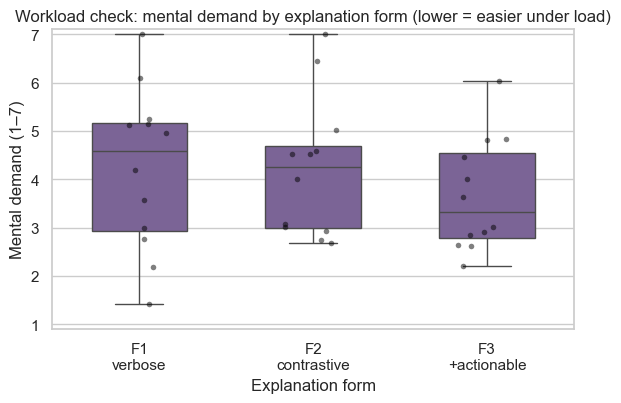

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.2))
sns.boxplot(data=table, x="form", y="workload", order=FORM_ORDER,
            color="#7a5c9e", width=0.55, ax=ax)
sns.stripplot(data=table, x="form", y="workload", order=FORM_ORDER,
              color="black", alpha=0.5, size=4, jitter=0.18, ax=ax)
ax.set_ylim(0.9, 7.1)
ax.set_xlabel("Explanation form")
ax.set_ylabel("Mental demand (1–7)")
ax.set_xticks(range(len(FORM_ORDER)))
ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
ax.set_title("Workload check: mental demand by explanation form (lower = easier under load)")
fig.tight_layout()
fig.savefig(OUT / "workload_by_form.png", dpi=150)
plt.show()

**Figure 2 — within-subject view.** Each grey line is one participant across the
three forms; the thick line is the mean. Because the design is within-subjects,
this shows whether *individuals* tend to feel less loaded under F2/F3, not just the
group average.

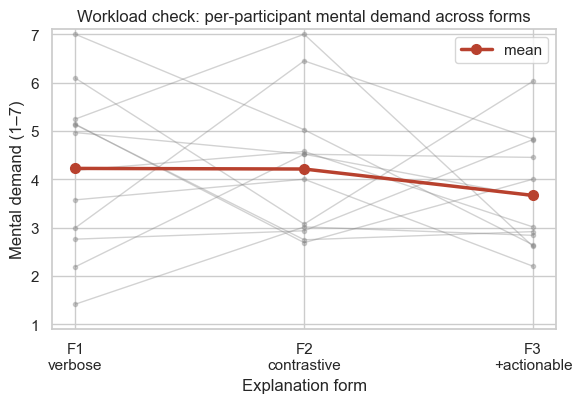

In [6]:
wide = table.pivot_table(index="participant", columns="form", values="workload")
wide = wide.reindex(columns=FORM_ORDER)

fig, ax = plt.subplots(figsize=(6, 4.2))
x = np.arange(len(FORM_ORDER))
for _, row in wide.iterrows():
    ax.plot(x, row.values, color="grey", alpha=0.35, marker="o", markersize=3,
            linewidth=1)
ax.plot(x, wide.mean(axis=0).values, color="#b8412e", marker="o", markersize=7,
        linewidth=2.5, label="mean")
ax.set_xticks(x)
ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
ax.set_ylim(0.9, 7.1)
ax.set_xlabel("Explanation form")
ax.set_ylabel("Mental demand (1–7)")
ax.set_title("Workload check: per-participant mental demand across forms")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "workload_perparticipant.png", dpi=150)
plt.show()

## 3. Workload as the mechanism behind explicability

The workload check is only useful if reduced load tracks the predicted gains in
objective explicability (H2). This section plots mean `workload` against mean
`mm_explicability` per form. The mechanism predicts an **inverse** relationship —
the form that costs least to process (lowest workload) should leave the
best-calibrated mental model (highest explicability): F2/F3 in the low-load /
high-explicability corner, F1 in the high-load / lower-explicability corner.

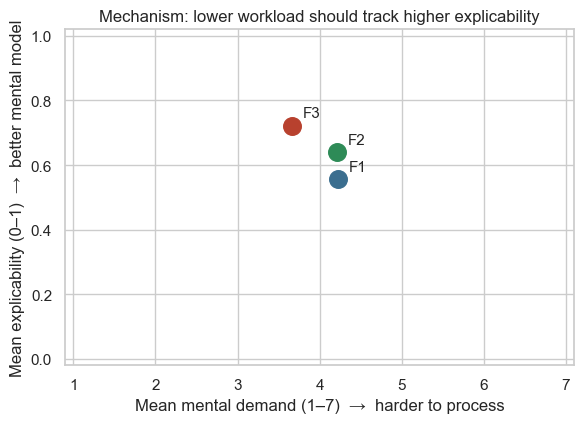

In [7]:
means = (table.groupby("form")[["workload", "mm_explicability"]]
              .mean().reindex(FORM_ORDER))
COLORS = {"F1": "#3b6e8f", "F2": "#2e8b57", "F3": "#b8412e"}

fig, ax = plt.subplots(figsize=(6, 4.4))
for form, row in means.iterrows():
    ax.scatter(row["workload"], row["mm_explicability"], s=160,
               color=COLORS[form], zorder=3)
    ax.annotate(form, (row["workload"], row["mm_explicability"]),
                textcoords="offset points", xytext=(8, 6), fontsize=11)
ax.set_xlim(0.9, 7.1)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Mean mental demand (1–7)  →  harder to process")
ax.set_ylabel("Mean explicability (0–1)  →  better mental model")
ax.set_title("Mechanism: lower workload should track higher explicability")
fig.tight_layout()
fig.savefig(OUT / "workload_vs_explicability.png", dpi=150)
plt.show()

## 4. Compact summary table

One row per form, suitable for the report. The mechanism predicts `workload` to be
**highest under F1** and lowest under F2/F3 (shown alongside the explicability
composite, which should move in the opposite direction).

In [8]:
SUMMARY_COLS = ["workload", "mm_explicability"]
summary = (table.groupby("form")[SUMMARY_COLS]
              .agg(["mean", "median", "std"])
              .reindex(FORM_ORDER)
              .round(3))
summary.to_csv(OUT / "workload_summary_by_form.csv")
summary

workload               mm_explicability              
         mean median    std             mean median    std
form                                                      
F1      4.223  4.574  1.667            0.556  0.667  0.328
F2      4.211  4.258  1.435            0.639  0.667  0.332
F3      3.665  3.323  1.167            0.722  0.667  0.278